# Unit 4: 实时 EEG 数据可视化

## 学习目标
- 掌握 matplotlib.animation 实现数据动画刷新
- 实现多通道 EEG 信号的实时滚动显示
- 构建可配置的实时波形显示器
- 理解缓冲区管理与渲染性能优化
- 了解交互式可视化组件（ipywidgets）的使用

## 核心概念

### 实时可视化的挑战
- **数据速率**：Cyton 以 250 Hz 采样，8 通道每秒产生 2000 个数据点
- **渲染性能**：需要在数据到达速率内完成绘图更新
- **缓冲区管理**：仅显示最近 N 秒数据，避免内存溢出
- **UI 流畅度**：避免绘图操作阻塞数据采集

### 技术选型
- `matplotlib.animation.FuncAnimation`：基于定时器的动画框架
- `set_ydata()` / `set_xdata()`：仅更新数据线，避免重绘整个画布
- `deque`：高效的 FIFO 环形缓冲区

## 1. 环境准备

In [1]:
import time
from collections import deque
from typing import List, Optional, Tuple

import numpy as np
from scipy import signal as scipy_signal

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

print("Modules imported successfully.")

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

Modules imported successfully.


## 2. 模拟数据源

模拟实时到达的 EEG 数据流（替代真实硬件）。

In [2]:
class SimulatedEEGSource:
    """
    模拟实时 EEG 数据源
    
    功能:
        - 按采样率生成逼真的 EEG 数据
        - 支持批量获取样本
        - 可配置信噪比和伪影
    """
    
    def __init__(
        self,
        n_channels: int = 8,
        sfreq: float = 250.0,
        noise_level: float = 5.0
    ):
        """
        Args:
            n_channels: 通道数
            sfreq: 采样频率（Hz）
            noise_level: 噪声标准差（uV）
        """
        self.n_channels = n_channels
        self.sfreq = sfreq
        self.noise_level = noise_level
        self.sample_counter = 0
        np.random.seed(42)
    
    def get_samples(self, n_samples: int = 10) -> np.ndarray:
        """
        生成并返回n_samples个样本(n_channels, n_samples)
        
        Args:
            n_samples: 获取的样本数
        
        Returns:
            形状为 (n_channels, n_samples) 的数组
        """
        samples = np.zeros((self.n_channels, n_samples))
        
        for s in range(n_samples):
            # 计算当前时间点（秒）
            # 从当前样本计数器开始，每个样本间隔为 1/采样率
            t = (self.sample_counter + s) / self.sfreq
            
            for ch in range(self.n_channels):
                # Alpha 波 (10 Hz)，通道间有相位差
                alpha = 20 * np.sin(2 * np.pi * 10 * t + ch * 0.3)
                # Theta 波 (6 Hz)
                theta = 10 * np.sin(2 * np.pi * 6 * t + ch * 0.5)
                # Beta 波 (20 Hz)
                beta = 5 * np.sin(2 * np.pi * 20 * t)
                # 噪声
                noise = np.random.randn() * self.noise_level
                # 偶尔的眨眼伪影
                blink = 0
                if np.random.random() < 0.002:  # 0.2% 概率
                    blink = 80 * np.random.randn()
                
                samples[ch, s] = alpha + theta + beta + noise + blink
        
        self.sample_counter += n_samples
        return samples # (n_channels, n_samples)
    
    def reset(self):
        """重置计数器"""
        self.sample_counter = 0

# 测试数据源
src = SimulatedEEGSource()
test_data = src.get_samples(5)
print(f"Generated sample shape: {test_data.shape}")
print(f"First 3 samples of Channel 1: {test_data[0, :3]}")

Generated sample shape: (8, 5)
First 3 samples of Channel 1: [ 2.48357077 10.09463336 13.82393548]


## 3. 实时滚动显示核心类

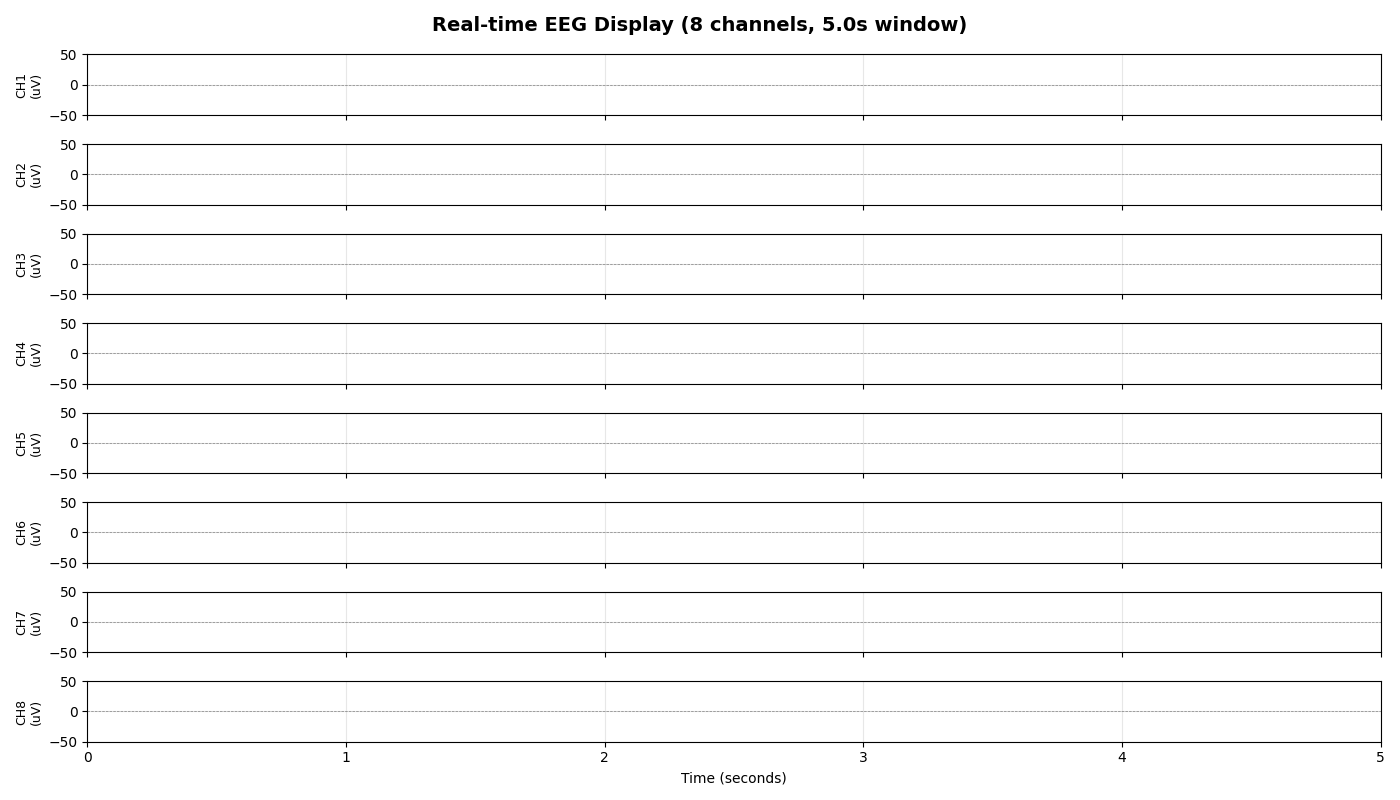

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

class EEGRealtimePlotter:
    """
    实时 EEG 多通道滚动显示器
    
    功能:
        - 多通道独立子图显示
        - 可配置时间窗口
        - 支持数据缩放与偏移
        - 自动 Y 轴范围调整
    """
    
    def __init__(
        self,
        n_channels: int = 8,
        sfreq: float = 250.0,
        window_seconds: float = 5.0,
        channel_labels: Optional[List[str]] = None,
        y_scale: float = 50.0
    ):
        """
        Args:
            n_channels: 通道数量
            sfreq: 采样频率（Hz）
            window_seconds: 显示时间窗口（秒）
            channel_labels: 通道名称列表
            y_scale: 每通道的 Y 轴缩放因子（uV）
        """
        self.n_channels = n_channels
        self.sfreq = sfreq
        self.window_seconds = window_seconds
        self.max_samples = int(sfreq * window_seconds)
        self.y_scale = y_scale
        
        # 默认通道标签：使用通用编号 CH1, CH2
        if channel_labels is None:
            self.channel_labels = [f'CH{i+1}' for i in range(n_channels)]
        else:
            self.channel_labels = channel_labels[:n_channels]
        
        # 数据缓冲区（使用 deque 实现高效的 FIFO）
        # 最多存 window_seconds 秒数据
        # buffers (n_channels, max_samples)
        self.buffers: List[deque] = [deque(maxlen=self.max_samples) for _ in range(n_channels)] # 数据缓冲区
        self.time_buffer: deque[float] = deque(maxlen=self.max_samples)
        
        # 绘图相关
        self.fig = None
        self.axes = None
        self.lines = None
        self.animation = None
        self.start_time = None
        self.sample_index = 0  # 全局采样点计数器，用来生成稳定时间轴
        self.data_source: Optional[SimulatedEEGSource] = None  # 数据源
        self.update_interval_ms = 50  # 刷新间隔（毫秒）
    
 
    def setup_figure(self):
        """创建空的图表和坐标轴"""
        self.fig, self.axes = plt.subplots(
            self.n_channels, 1, 
            figsize=(14, 1 * self.n_channels),
            sharex=True
        )
        
        # 确保 axes 是列表（单通道情况）
        if self.n_channels == 1:
            self.axes = [self.axes]
        
        # 总标题：显示通道数和窗口时间
        self.fig.suptitle(
            f'Real-time EEG Display ({self.n_channels} channels, {self.window_seconds}s window)',
            fontsize=14, fontweight='bold'
        )
        
        self.lines: List[plt.Line2D] = []
        for i, ax in enumerate(self.axes):
            line, = ax.plot([], [], linewidth=0.8, color=f'C{i}')
            ax.set_ylabel(f'{self.channel_labels[i]}\n(uV)', fontsize=9)
            ax.set_ylim(-self.y_scale, self.y_scale)
            ax.set_xlim(0, self.window_seconds)
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)  # 基线
            self.lines.append(line)
        
        self.axes[-1].set_xlabel('Time (seconds)')
        plt.tight_layout()
    
    def add_data(self, new_data: np.ndarray):
        """
        添加新数据到缓冲区
        
        Args:
            new_data: 形状为 (n_channels, n_samples) 的新数据
        """
        if self.start_time is None:
            self.start_time = time.time()
        
        new_data_number = new_data.shape[1]  # 新数据样本数

        # 每个样本的时间戳由 sample_index / sfreq 决定
        # 不再依赖 time.time()，避免系统刷新抖动影响时间轴
        for i in range(new_data_number):
            t = self.sample_index / self.sfreq
            self.time_buffer.append(t)

            for ch in range(self.n_channels):
                self.buffers[ch].append(new_data[ch, i])

            self.sample_index += 1
    
    def update_plot(self, frame):
        """
        动画更新函数（由 FuncAnimation 调用）
        
        Args:
            frame: 当前帧号（由 FuncAnimation 自动传递）
        """
        # update_interval_ms 毫秒刷新一次图像
        # 大概需要新的12个采样点
        samples_per_update = max(1, int(self.sfreq * (self.update_interval_ms / 1000)))
        if self.data_source is not None:
            # 从数据源获取12个数据
            new_data = self.data_source.get_samples(samples_per_update)
            self.add_data(new_data) # 添加新数据到缓冲区
        
        # 因为画一条线至少需要两个点。
        # 只有 0 个或 1 个采样点时，曲线还没法正常显示，所以直接返回当前的线对象。
        if len(self.time_buffer) < 2:
            return self.lines
        
        time_data = np.array(self.time_buffer)
        # 最新点固定在窗口右侧
        # 给新数据安排x轴时间
        # 随着新数据的添加，time_data[-1]越来越大
        # time_data里面的老数据会向左移动
        time_data = time_data - time_data[-1] + self.window_seconds
        
        # 更新每条线
        for ch in range(self.n_channels):
            # 更新当前通道的数据
            channel_data = np.array(self.buffers[ch])
            # 更新当前通道的线数据
            self.lines[ch].set_data(time_data, channel_data)
        

        data_elapsed = self.sample_index / self.sfreq
        self.fig.suptitle(
            f'Real-time EEG Display | Data Time: {data_elapsed:.1f}s | '
            f'frame: {frame+1}',
            fontsize=14, fontweight='bold'
        )
        
        return self.lines
    
    def start_animation(self, data_source, duration_seconds: Optional[float] = None):
        """
        启动动画
        
        Args:
            data_source: SimulatedEEGSource 实例
            duration_seconds: 动画持续时间（秒），None 表示无限
        """
        self.data_source = data_source
        self.setup_figure()
        
        frames = None
        if duration_seconds is not None:
            # 计算总帧数
            frames = int(duration_seconds * 1000 / self.update_interval_ms)
        
        self.animation = FuncAnimation(
            self.fig,
            self.update_plot, # 动画更新函数
            frames=frames,    # 总帧数
            interval=self.update_interval_ms,
            blit=False,
            repeat=False
        )
        
        plt.show()
    
    def get_current_data(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        获取当前缓冲区中的所有数据
        
        Returns:
            time_array: 时间数组 List[deque]
            eeg_array: (n_channels, n_samples) 数据
        """
        time_array = np.array(self.time_buffer)
        eeg_array = np.array([list(b) for b in self.buffers])
        return time_array, eeg_array

# 数据源实例
data_source = SimulatedEEGSource(
    n_channels=8,
    sfreq=250.0,
    noise_level=0.5
)

plotter = EEGRealtimePlotter(
    n_channels=8,
    sfreq=250.0,
    window_seconds=5.0  # 缓存里最多存5秒数据
)

plotter.start_animation(data_source, duration_seconds=10.0)


## 4. 静态多通道可视化（替代方案）

当无法运行动画时，展示静态但信息丰富的多通道可视化。

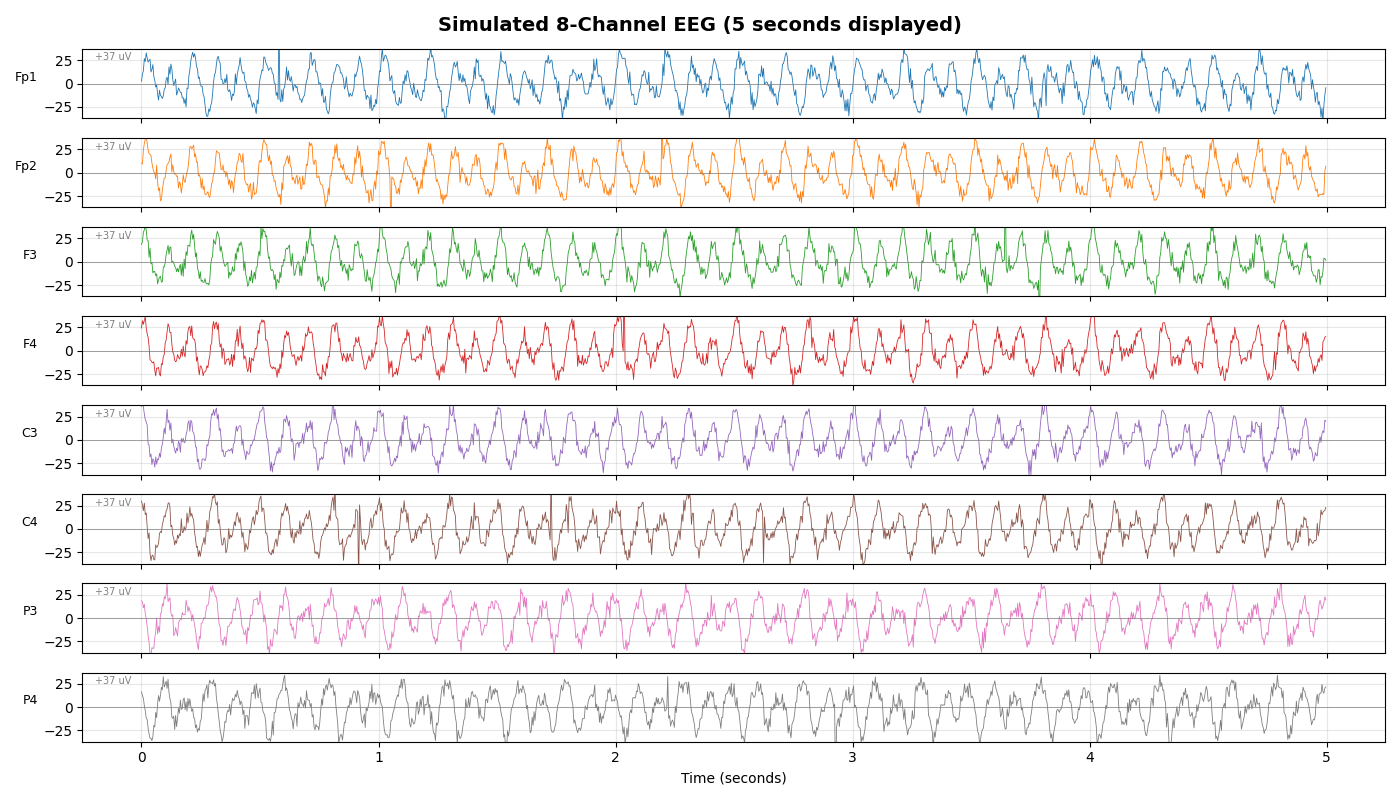

In [4]:
def plot_multichannel_eeg(
    data: np.ndarray,
    sfreq: float = 250.0,
    channel_labels: Optional[List[str]] = None,
    window_sec: Optional[float] = None,
    title: str = "8-Channel EEG Recording"
) -> plt.Figure:
    """
    绘制多通道 EEG 波形图
    
    Args:
        data: (n_channels, n_samples) 数据
        sfreq: 采样频率
        channel_labels: 通道标签
        window_sec: 仅显示前 N 秒
        title: 图表标题
    """
    n_channels = data.shape[0]
    n_samples = data.shape[1]
    
    if window_sec is not None:
        n_samples = min(n_samples, int(window_sec * sfreq))
    
    time_axis = np.arange(n_samples) / sfreq # 时间轴，单位秒
    
    if channel_labels is None:
        channel_labels = [f'CH{i+1}' for i in range(n_channels)]
    
    fig, axes = plt.subplots(n_channels, 1, figsize=(14, 1 * n_channels), sharex=True)
    
    if n_channels == 1:
        axes = [axes]
    
    # 自动计算 Y 轴范围
    # 取绝对值数据中的 95 分位数
    # 有 95% 的振幅都小于等于这个值
    # 只有 5% 的振幅比它更大
    y_max = np.percentile(np.abs(data[:, :n_samples]), 95) * 1.2
    
    for i, ax in enumerate(axes):
        ax.plot(time_axis, data[i, :n_samples], linewidth=0.6, color=f'C{i}')
        ax.set_ylabel(f'{channel_labels[i]}', fontsize=9, rotation=0, ha='right')
        ax.set_ylim(-y_max, y_max)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
        ax.text(
            0.01,  # x 坐标（相对于坐标轴的百分比位置）
            0.95,  # y 坐标（相对于坐标轴的百分比位置）
            f'+{y_max:.0f} uV',  # 显示的文本内容（最大振幅值）
            transform=ax.transAxes,  # ax.transAxes：把当前 ax 的显示区域当成 0~1 的坐标系来定位文字
            fontsize=7,  # 字体大小
            va='top',  # 垂直对齐方式：顶部对齐
            alpha=0.5  # 透明度（0-1，值越小越透明）
        )
    
    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig


# 生成 10 秒模拟数据并显示
sim_source = SimulatedEEGSource(n_channels=8, sfreq=250, noise_level=5)
eeg_data = sim_source.get_samples(250 * 10)  # 10 秒

# 使用 10-20 系统命名
standard_labels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4']

fig = plot_multichannel_eeg(
    eeg_data,
    sfreq=250,
    channel_labels=standard_labels,
    window_sec=5,
    title="Simulated 8-Channel EEG (5 seconds displayed)"
)
plt.show()

## 5. 交互式缩放与通道选择

In [5]:
import mne
mne.sys_info()

Platform             Windows-10-10.0.26200-SP0
Python               3.10.20 (main, May  4 2026, 21:16:22) [MSC v.1944 64 bit (AMD64)]
Executable           d:\AI\trae_solo\Brain\openbci-3\.venv\Scripts\python.exe
CPU                  Intel(R) Core(TM) i7-10700KF CPU @ 3.80GHz (16 cores)
Memory               31.9 GiB

Core
 + mne               1.12.1 (unable to check for latest version on GitHub, unknown error: HTTP Error 403: rate limit exceeded)
 + numpy             2.2.6 (OpenBLAS 0.3.29 with 16 threads)
 + scipy             1.15.3
 + matplotlib        3.10.9 (backend=widget)

Numerical (optional)
 + sklearn           1.7.2
 + pandas            2.3.3
 - unavailable       numba, nibabel, nilearn, dipy, openmeeg, cupy, h5io, h5py

Visualization (optional)
 + pyvista           0.48.2 (OpenGL 4.5.0 NVIDIA 591.86 via NVIDIA GeForce RTX 3070/PCIe/SSE2)
 + pyvistaqt         0.11.4
 + vtk               9.6.1
 + ipympl            0.10.0
 + ipywidgets        8.1.8
 - unavailable       qtpy, pyq

In [6]:
# 使用 ipywidgets 创建交互式可视化
try:
    import time
    from collections import deque
    from typing import List, Optional, Tuple

    import numpy as np
    from scipy import signal as scipy_signal
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt

    
    class InteractiveEEGViewer:
        """交互式 EEG 数据查看器"""
        
        def __init__(self, data: np.ndarray, sfreq: float = 250.0, labels: Optional[List[str]] = None):
            self.data = data
            self.sfreq = sfreq
            self.n_channels, self.n_samples = data.shape
            self.labels = labels or [f'CH{i+1}' for i in range(self.n_channels)]
            self.total_duration = self.n_samples / self.sfreq
            
            self._build_ui()
        
        def _build_ui(self):
            # 这是起始时间滑块，用于调整显示的起始时间点
            self.start_slider = widgets.FloatSlider(
                value=0,  # 初始值：起始时间从0秒开始
                min=0,  # 最小值：起始时间不能小于0秒
                max=max(0, self.total_duration - 1),  # 最大值：总时长减1秒，确保窗口有显示空间
                step=0.1,  # 步长：每次滑动调整0.1秒
                description='Start (s)',  # 标签：显示"Start (s)"
                continuous_update=True,  # 连续更新：滑动时实时更新
                layout=widgets.Layout(width='100%')  # 布局宽度：占100%
            )
            # 这是窗口时间滑块，用于调整显示的窗口时间
            # 初始值：默认5秒或总时长（取较小值）
            # 最小值：窗口最小0.5秒
            # 最大值：不能超过总时长
            # 步长：每次滑动调整0.1秒
            # 标签：显示"Window (s)"
            self.window_slider = widgets.FloatSlider(
                value=min(5, self.total_duration),  # 初始值：默认5秒或总时长（取较小值）
                min=0.5,  # 最小值：窗口最小0.5秒
                max=self.total_duration,  # 最大值：不能超过总时长
                step=0.1,  # 步长：每次滑动调整0.1秒
                description='Window (s)',  # 标签：显示"Window (s)"
                continuous_update=False,  # 非连续更新：释放滑块后才更新
                layout=widgets.Layout(width='100%')  # 布局宽度：占100%
            )
            # 这是Y轴缩放滑块，用于调整显示的Y轴范围
            # 初始值：默认50微伏
            # 最小值：最小缩放10微伏
            # 最大值：最大缩放200微伏
            # 步长：每次调整5微伏
            # 标签：显示"Y Scale (uV)"
            self.y_scale_slider = widgets.FloatSlider(
                value=50,  # 初始值：Y轴范围±50微伏
                min=10,  # 最小值：最小缩放10微伏
                max=200,  # 最大值：最大缩放200微伏
                step=5,  # 步长：每次调整5微伏
                description='Y Scale (uV)',  # 标签：显示"Y Scale (uV)"
                continuous_update=False,  # 非连续更新：释放滑块后才更新
                layout=widgets.Layout(width='100%')  # 布局宽度：占100%
            )
            # 这是通道选择器，用于选择要显示的通道
            # 初始值：默认选中前4个或全部通道
            # 标签：显示"Channels"
            self.channel_selector = widgets.SelectMultiple(
                options=[(self.labels[i], i) for i in range(self.n_channels)],  # 选项：通道名称和索引
                value=tuple(range(min(4, self.n_channels))),  # 初始值：默认选中前4个或全部通道
                description='Channels',  # 标签：显示"Channels"
                layout=widgets.Layout(width='100%', height='150px')  # 布局：宽度100%，高度150像素
            )
            
            # 输出区域
            self.output = widgets.Output()
            
            # 绑定事件
            self.start_slider.observe(self._on_change, 'value')
            self.window_slider.observe(self._on_change, 'value')
            self.y_scale_slider.observe(self._on_change, 'value')
            self.channel_selector.observe(self._on_change, 'value')
            
            controls = widgets.VBox(
                [
                    self.start_slider,
                    self.window_slider,
                    self.y_scale_slider,
                    self.channel_selector
                ],
                layout=widgets.Layout(
                    width='300px',
                    min_width='300px',
                    flex='0 0 300px'
                )
            )

            self.output = widgets.Output(
                layout=widgets.Layout(
                    # width='600px',
                    overflow='auto'
                )
            )

            self.ui = widgets.HBox(
                [controls, self.output],
                layout=widgets.Layout(
                    width='100%',
                    align_items='flex-start'
                )
            )
            
            # 初始绘图
            self._update_plot()
        
        # 被动更新
        def _on_change(self, change):
            self._update_plot()
        
        # 更新图表
        def _update_plot(self):
            with self.output:
                clear_output(wait=True)
                
                start = self.start_slider.value
                window = self.window_slider.value
                y_scale = self.y_scale_slider.value
                selected_channels = list(self.channel_selector.value)
                
                if not selected_channels:
                    print("Please select at least one channel.")
                    return
                
                start_idx = int(start * self.sfreq)
                end_idx = int((start + window) * self.sfreq)

                start_idx = max(0, min(start_idx, self.n_samples - 1))
                end_idx = max(start_idx + 1, min(end_idx, self.n_samples))

                time_axis = np.arange(start_idx, end_idx) / self.sfreq
                actual_start = start_idx / self.sfreq
                actual_end = end_idx / self.sfreq
                
                n_sel = len(selected_channels)
                fig, axes = plt.subplots(n_sel, 1, figsize=(12, 2 * n_sel), sharex=True)
                if n_sel == 1:
                    axes = [axes]
     
                
                for i, ch_idx in enumerate(selected_channels):
                    axes[i].plot(time_axis, self.data[ch_idx, start_idx:end_idx], 
                                linewidth=0.6, color=f'C{i}')
                    axes[i].set_ylabel(f'{self.labels[ch_idx]}', fontsize=9, rotation=0, ha='right')
                    axes[i].set_ylim(-y_scale, y_scale)
                    axes[i].grid(True, alpha=0.3)
                    axes[i].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
                
                axes[-1].set_xlabel('Time (seconds)')
                fig.suptitle(
                    f'EEG Viewer | {actual_start:.1f}s - {actual_end:.1f}s',
                    fontsize=12
                )
                plt.tight_layout()
                plt.show()
        
        def display(self):
            display(self.ui)
    
    # 创建交互式查看器
    viewer = InteractiveEEGViewer(eeg_data, sfreq=250, labels=standard_labels)
    viewer.display()
    
except ImportError:
    print("ipywidgets not available. Install with: pip install ipywidgets")
    print("Running static visualization instead.")

## 6. 叠加平均显示（ERP 可视化）

Number of events: 5


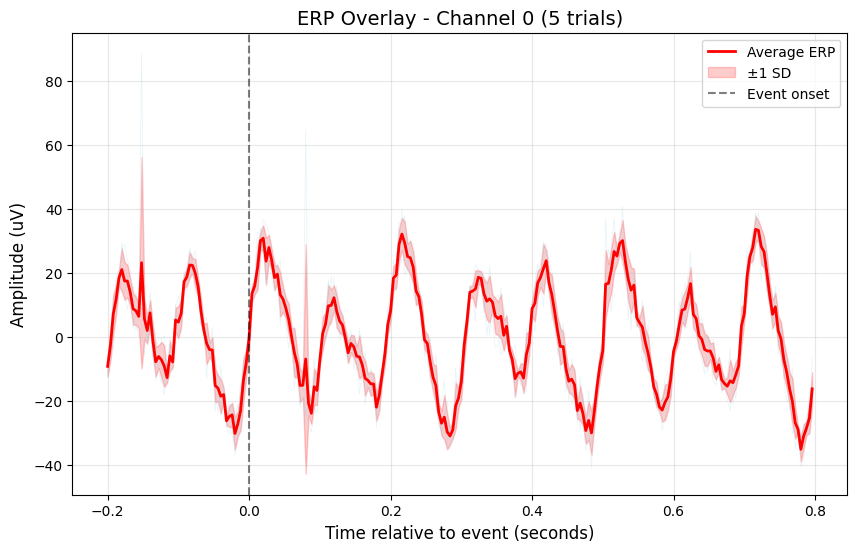

In [8]:
def plot_erp_overlay(
    data: np.ndarray,
    sfreq: float,
    event_indices: List[int],
    tmin: float = -0.2,
    tmax: float = 0.8,
    channel: int = 0
) -> plt.Figure:
    """
    绘制事件相关电位（ERP）叠加图
    
    Args:
        data: (n_channels, n_samples) EEG 数据
        sfreq: 采样频率
        event_indices: 事件触发点的样本索引列表
        tmin: 事件前时间（秒，通常为负值）
        tmax: 事件后时间（秒）
        channel: 要显示的通道索引
    """
    n_pre = int(abs(tmin) * sfreq) # 事件前时间样本数
    n_post = int(tmax * sfreq)     # 事件后时间样本数
    epoch_length = n_pre + n_post
    
    epochs = []
    for idx in event_indices:
        start = idx - n_pre
        end = idx + n_post
        if start >= 0 and end <= data.shape[1]:
            epochs.append(data[channel, start:end])  # shape(n_epoch, nchannel, n_samples)
    
    if not epochs:
        print("No valid epochs found.")
        return None
    
    epochs = np.array(epochs)
    mean_epoch = np.mean(epochs, axis=0) # (nchannel, n_samples)
    time_axis = np.arange(epoch_length) / sfreq + tmin  # 时间轴
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 绘制单个 trial
    for epoch in epochs:
        ax.plot(time_axis, epoch, color='lightblue', alpha=0.3, linewidth=0.5)
    
    # 绘制平均
    ax.plot(time_axis, mean_epoch, color='red', linewidth=2, label='Average ERP')
    
    # 添加标准差带
    std_epoch = np.std(epochs, axis=0) # (nchannel, n_samples)
    ax.fill_between(time_axis, mean_epoch - std_epoch, mean_epoch + std_epoch,
                    color='red', alpha=0.2,label='±1 SD')
    
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Event onset')
    ax.set_xlabel('Time relative to event (seconds)', fontsize=12)
    ax.set_ylabel('Amplitude (uV)', fontsize=12)
    ax.set_title(f'ERP Overlay - Channel {channel} ({len(epochs)} trials)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig


# 模拟 ERP 实验：每 2 秒一个事件
# range(start, stop, step)
# 从 0.5 ~ 10 ，每 2 秒一个事件
event_indices = list(range(int(0.5 * 250), 250 * 10, int(2 * 250))) # 事件触发点的样本索引列表
print(f"Number of events: {len(event_indices)}")

%matplotlib inline
fig_erp = plot_erp_overlay(
    eeg_data, sfreq=250,
    event_indices=event_indices,
    tmin=-0.2, tmax=0.8,
    channel=0
)
if fig_erp:
    plt.show()

## 7. 知识点总结

### 实时可视化关键技术
1. **`deque(maxlen=N)`**：自动淘汰旧数据的高效环形缓冲区
2. **`set_data()`**：更新线条数据而非重建，提升渲染效率
3. **`FuncAnimation`**：基于定时器的动画框架，`interval` 控制刷新率
4. **`blit=True`**：仅重绘变化部分，大幅提升性能（但与某些后端不兼容）

### 性能优化建议
- 每次更新只获取少量样本（如 10-20 个），减少内存拷贝
- 限制缓冲区大小，避免内存泄漏
- 使用 `sharex=True` 减少 X 轴重复绘制
- 对于超过 16 通道的显示，考虑使用瀑布图或热图

## 8. 练习任务

1. 修改 `EEGRealtimePlotter`，添加实时 PSD 频谱显示子图
2. 实现一个简易的触发标记功能：按键时在当前时间点添加标记线
3. 添加颜色映射：根据信号幅度动态改变线条颜色
4. 实现一个瀑布图（waterfall plot）显示多通道频谱随时间变化

---
*参考资料: [Matplotlib Animation](https://matplotlib.org/stable/api/animation_api.html)*